In [3]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy.optimize import minimize
from graph_format import *
import matplotlib.pyplot as plt

wages = pd.read_csv("Data_cohort/wage.csv").iloc[:, 1]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def sum_hours(t, delta):
    total = 0
    for i in range(t):
        total += (1 - delta) ** i
    return total

def objective_function(params, wages, w, delta_est):
    k0, beta1, beta2 = params
    total_error = 0
    for t in range(4, len(wages)):
        error_mean = (
            np.log(wages[t - 4])
            - np.log(w)
            - beta1 * (1 - delta_est) ** t * k0
            - beta1 * (sum_hours(t, delta_est))
            - beta2 * t**2
        )

        total_error += error_mean **2
    return total_error

initial_guess = [11.303549, 0.061654, -0.000375, ]
bounds = [(1, 30), (0.001, 0.08), (-0.0005, 0), ]

def random_initial_guess(bounds):
    # np.random.seed(1)
    return [np.random.uniform(low, high) for low, high in bounds]

initial_guess = random_initial_guess(bounds)

w_est = 21940*12
delta_est = 0.03

result = minimize(
    objective_function,
    x0=initial_guess,
    args=(wages, w_est, delta_est),
    method="nelder-mead",
    bounds=bounds,
    tol=1e-9,
    options={
        "maxiter": 30000,  # Maximum iterations
        "xatol": 1e-9,
        "fatol": 1e-9, 
        "disp": True
    }
)


estimated_params = result.x
k0_est, beta1_est, beta2_est = estimated_params

results_dict = {
    "Parameter": ["par.w_0 =", "par.k_0 =", "par.beta_1 =", "par.beta_2 =", "par.delta ="],
    "Estimated Value": [w_est, k0_est, beta1_est, beta2_est, delta_est],
}

results_df = pd.DataFrame(results_dict)

print(results_df)

print(result.fun)

Optimization terminated successfully.
         Current function value: 0.000088
         Iterations: 170
         Function evaluations: 330
      Parameter  Estimated Value
0     par.w_0 =    263280.000000
1     par.k_0 =        11.588177
2  par.beta_1 =         0.024787
3  par.beta_2 =        -0.000042
4   par.delta =         0.030000
8.84212074380528e-05


In [5]:
def simulate(params, wages, w, delta_est):
    k0, beta1, beta2 = params
    ln_wage = np.zeros(len(wages) + 4)
    for t in range(len(wages) + 4):
        ln_wage[t] = (
            np.log(w)
            + beta1 * (1 - delta_est) ** t * k0
            + beta1 * (sum_hours(t, delta_est))
            + beta2 * t**2
        )

    return ln_wage


In [6]:
# Extend wages with 4 additional values to match the length of simulated wages

wages_ext = np.concatenate((np.full(4, np.nan), wages))


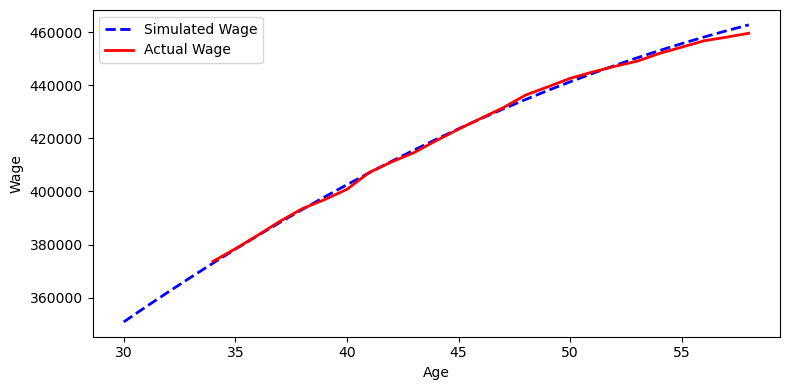

In [7]:
wages_sim = simulate(estimated_params, wages, w_est, delta_est)

plot_wages(np.exp(wages_sim), wages_ext)


In [8]:
from model import ModelClass
import numpy as np

model = ModelClass() # set a few number of periods.

par = model.par
sol = model.sol
sim = model.sim

model.allocate_sim()

In [ ]:
np.sum(sim.k_init == 0) / 10000

0.0249

: 

: 

: 

: 

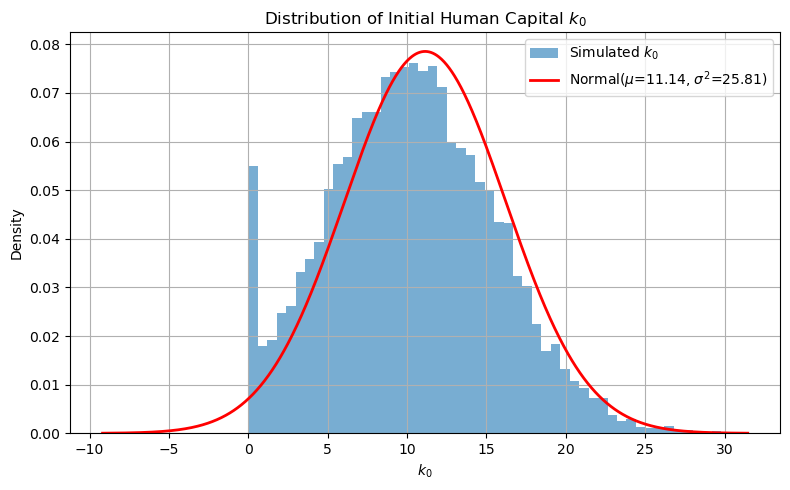

: 

: 

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Your data
# sim.k_init is assumed to be a NumPy array already
# e.g., sim.k_init = np.array([...])

# Parameters of the normal distribution to compare against
mu = 11.14
variance = 5.08**2  # If you actually mean std^2
sigma = np.sqrt(variance)

# x range
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf = norm.pdf(x, loc=mu, scale=sigma)

# Plot
plt.figure(figsize=(8, 5))

# Histogram of your simulated initial human capital
plt.hist(sim.k_init, bins=50, density=True, alpha=0.6, label='Simulated $k_0$')

# Overlay the normal PDF
plt.plot(x, pdf, 'r-', linewidth=2, label=f'Normal($\mu$={mu}, $\sigma^2$={variance:.2f})')

plt.title('Distribution of Initial Human Capital $k_0$')
plt.xlabel('$k_0$')
plt.ylabel('Density')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
